In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Satya Meghana\Documents\HousePricePrediction_Meghana\Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
print("Rows and Columns:",df.shape)

Rows and Columns: (545, 13)


In [6]:
df.isnull().sum()


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
print("Target Column:")
print("price")

print("\nFeature Columns:")
print(df.columns.drop("price"))

Target Column:
price

Feature Columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [10]:
df_clean = pd.get_dummies(df, drop_first=True)

df_clean.head()


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [11]:
print(df_clean.shape)

(545, 14)


In [12]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

In [13]:
X = df_clean.drop("price", axis=1)
y = df_clean["price"]

print(X.shape)
print(y.shape)

(545, 13)
(545,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(436, 13)
(109, 13)


In [16]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 :", r2_score(y_test, y_pred_lr))

MAE : 970043.4039201635
RMSE: 1324506.9600914384
R2 : 0.6529242642153186


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [19]:
print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 :", r2_score(y_test, y_pred_rf))

MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R2 : 0.611918531405699


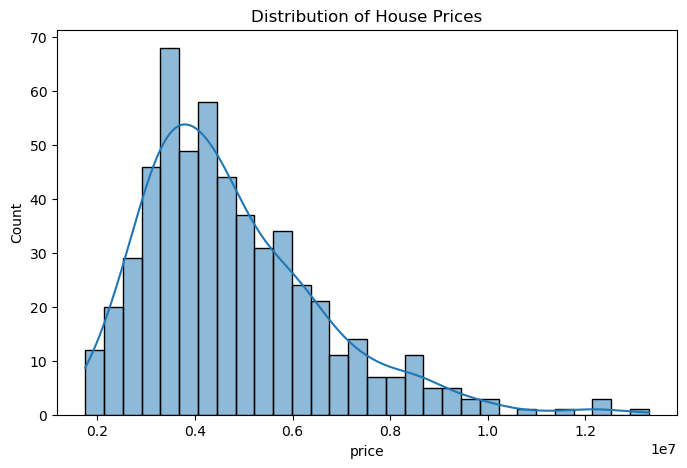

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.savefig("price_distribution.png")
plt.show()

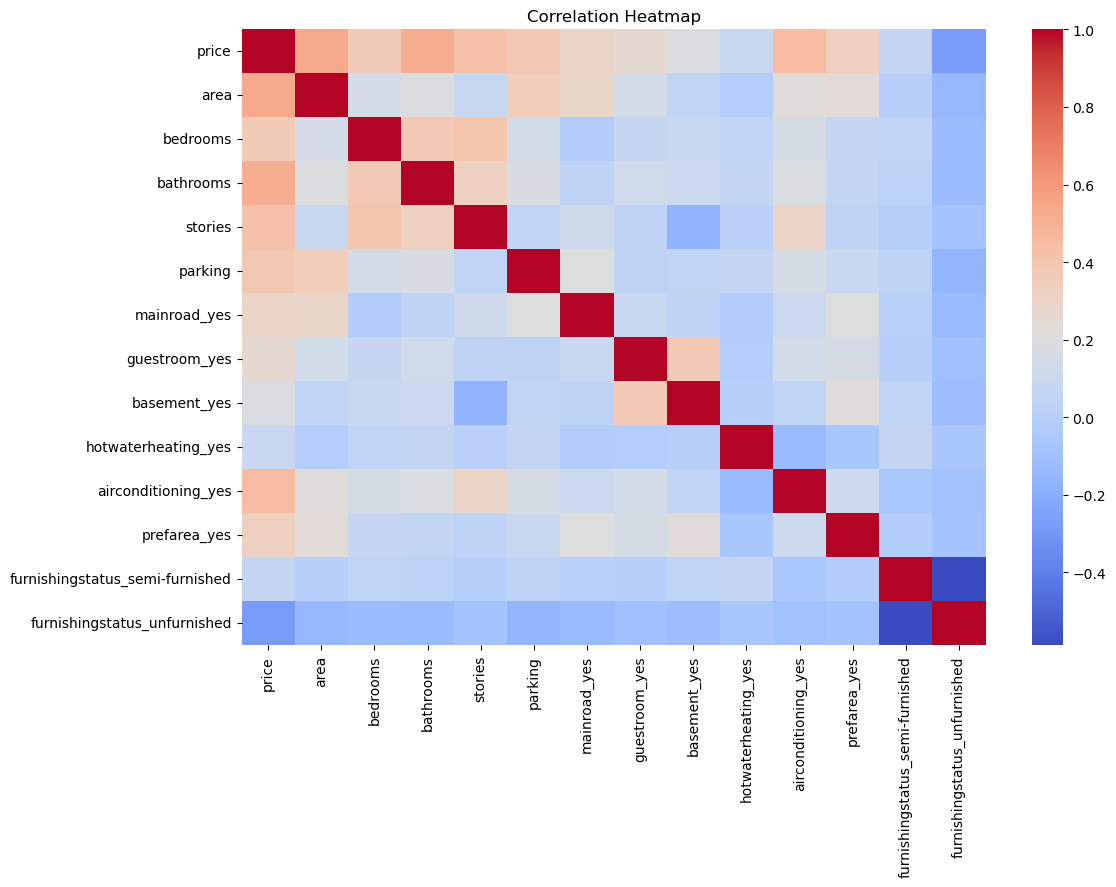

In [25]:
plt.figure(figsize=(12,8))

sns.heatmap(df_clean.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")

plt.show()

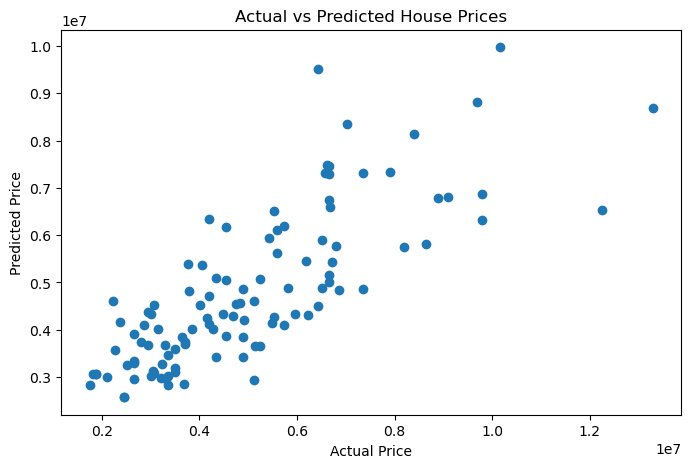

In [26]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")
plt.savefig("actual_vs_predicted.png")

plt.show()

In [23]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226
